# 任务1_2: 卷积神经网络 (CNN) 版本

本 Notebook 参考 task1_1.ipynb 的流程，改为 CNN 网络结构。

## 1) 安装与启动 Jupyter 内核（VS Code）

首次使用可在此单元安装依赖；运行后在 VS Code 右上角选择 Python 内核。

In [ ]:
# 如已安装可跳过
# %pip install -U pip
# %pip install ipykernel notebook torch torchvision pillow pandas matplotlib

# 导入 sys 用于查看当前内核的 Python 路径
import sys
# 输出当前解释器路径，确认内核环境
print(sys.executable)
# 输出提示信息，确认单元执行
print("内核已就绪")

d:\anaconda\envs\DL\python.exe
内核已就绪


In [ ]:
# 解决 Windows 下 OpenMP 重复加载导致的内核崩溃问题
# 导入 os 用于设置环境变量
import os
# 允许重复加载 OpenMP 库，避免特定环境崩溃
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# 打印确认信息
print("KMP_DUPLICATE_LIB_OK set")

KMP_DUPLICATE_LIB_OK set


## 2) 导入依赖并检查 PyTorch 版本

In [ ]:
# 基础库：路径、正则、随机数
import os
import re
import random
# 深度学习与数据处理相关
import torch
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# 打印 PyTorch 版本，确认环境
print("torch version:", torch.__version__)

torch version: 2.8.0+cpu


## 3) 配置数据路径（基于当前工作目录）

Notebook 中没有 __file__，这里使用当前工作目录并手动拼接数据路径。

In [ ]:
# 若你的 Notebook 不在该目录运行，可手动指定项目根目录
# 这里用当前工作目录的上一级作为默认根目录
project_root = os.path.dirname(os.getcwd())
# 例如：project_root = r"d:/CZ_WorkSpace/ai学习/深度学习实践"

# 拼接训练与测试数据集路径
train_dir = os.path.join(project_root, "MNIST_kaggle", "trainingSet")
test_dir = os.path.join(project_root, "MNIST_kaggle", "testSet")

# 打印路径与是否存在，便于排查数据路径问题
print("cwd:", os.getcwd())
print("project_root:", project_root)
print("train_dir exists:", os.path.exists(train_dir), "train_dir:", train_dir)
print("test_dir exists:", os.path.exists(test_dir), "test_dir:", test_dir)

cwd: d:\CZ_WorkSpace\ai学习\深度学习实践\task1\task1_2
project_root: d:\CZ_WorkSpace\ai学习\深度学习实践\task1
train_dir exists: True train_dir: d:\CZ_WorkSpace\ai学习\深度学习实践\task1\MNIST_kaggle\trainingSet
test_dir exists: True test_dir: d:\CZ_WorkSpace\ai学习\深度学习实践\task1\MNIST_kaggle\testSet


## 4) 定义 MyDataset（有标签/无标签双模式）

CNN 输入为 [1, 28, 28]，这里不再展平成 784。

In [ ]:
class MyDataset(Dataset):
    # 初始化数据集，支持有标签/无标签两种模式
    def __init__(self, data_dir, labeled=True):
        # 保存数据目录与标注标记
        self.data_dir = data_dir
        self.labeled = labeled
        # samples 保存 (路径, 标签) 或 路径
        self.samples = []
        # 定义统一的图像预处理流程
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((28, 28)),
            transforms.ToTensor(),
        ])

        # 如果是训练集，读取子目录作为类别
        if self.labeled:
            # 获取所有类别目录名
            class_names = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
            # 按数字顺序排序类别目录
            class_names = sorted(class_names, key=lambda x: int(x) if x.isdigit() else x)
            # 构建类别名到整数标签的映射
            self.class_to_idx = {name: int(name) for name in class_names}
            # 遍历每个类别目录收集样本
            for class_name in class_names:
                class_dir = os.path.join(data_dir, class_name)
                for file_name in os.listdir(class_dir):
                    # 只保留图片文件
                    if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                        file_path = os.path.join(class_dir, file_name)
                        label = self.class_to_idx[class_name]
                        self.samples.append((file_path, label))
        else:
            # 测试集无标签，仅保存图片路径
            self.class_to_idx = {}
            for file_name in os.listdir(data_dir):
                file_path = os.path.join(data_dir, file_name)
                # 只保留图片文件
                if os.path.isfile(file_path) and file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    self.samples.append(file_path)

    # 返回样本数量
    def __len__(self):
        return len(self.samples)

    # 获取单个样本
    def __getitem__(self, idx):
        # 根据是否有标签拆包
        if self.labeled:
            file_path, label = self.samples[idx]
        else:
            file_path = self.samples[idx]
            label = None

        # 读取图片并做预处理
        image = Image.open(file_path)
        image = self.transform(image)

        # 训练集返回 (图像张量, 标签)
        if self.labeled:
            return image, torch.tensor(label, dtype=torch.long)
        # 测试集返回 (图像张量, 文件路径)
        return image, file_path

## 5) 构建 DataLoader 并检查 batch 形状

In [ ]:
# 构建训练集 Dataset（有标签）
mydataset = MyDataset(data_dir=train_dir, labeled=True)
# 训练 DataLoader：打乱样本，提升训练随机性
mydataset_loader = DataLoader(mydataset, batch_size=64, shuffle=True)

# 构建测试集 Dataset（无标签）
test_dataset = MyDataset(data_dir=test_dir, labeled=False)
# 测试 DataLoader：不打乱，保持文件顺序
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 打印样本数量，检查数据是否加载成功
print(f"Train samples: {len(mydataset)}")
print(f"Test samples: {len(test_dataset)}")

# 简单查看前两个 batch 的形状与标签示例
for batch_idx, (images, labels) in enumerate(mydataset_loader):
    print(f"Batch {batch_idx}: images={images.shape}, labels={labels.shape}")
    print("Label sample:", labels[:10].tolist())
    if batch_idx == 1:
        break

Train samples: 42000
Test samples: 28000
Batch 0: images=torch.Size([64, 1, 28, 28]), labels=torch.Size([64])
Label sample: [3, 1, 1, 4, 5, 8, 0, 8, 0, 8]
Batch 1: images=torch.Size([64, 1, 28, 28]), labels=torch.Size([64])
Label sample: [9, 8, 6, 7, 1, 3, 0, 7, 6, 6]


## 6) 定义卷积神经网络 MyCNN

结构示例：Conv(1->16) -> ReLU -> MaxPool -> Conv(16->32) -> ReLU -> MaxPool -> FC。

In [ ]:
class MyCNN(nn.Module):
    # 初始化 CNN 网络结构
    def __init__(self):
        super(MyCNN, self).__init__()
        # 卷积特征提取部分
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # 分类器：展平后接全连接层输出 logits
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    # 前向传播逻辑
    def forward(self, x):
        # 提取卷积特征
        x = self.features(x)
        # 通过分类器得到最终输出
        x = self.classifier(x)
        return x

## 7) 定义评估函数 evaluate 与单样本推理 single_sample_check

In [ ]:
def evaluate(model, data_loader):
    # 若数据集为空或无标签，跳过评估
    if len(data_loader.dataset) == 0 or not data_loader.dataset.labeled:
        print("Warning: test set has no labels, skip accuracy evaluation.")
        return None

    # 切换到评估模式，关闭 dropout/bn 的训练行为
    model.eval()
    correct = 0
    total = 0
    # 评估阶段不需要梯度，节省显存与时间
    with torch.no_grad():
        for images, labels in data_loader:
            # 前向推理得到 logits
            outputs = model(images)
            # 取最大值所在类别作为预测结果
            preds = torch.argmax(outputs, dim=1)
            # 统计预测正确数量
            correct += (preds == labels).sum().item()
            # 统计样本总数
            total += labels.size(0)

    # 恢复训练模式，避免影响后续训练
    model.train()
    if total == 0:
        print("Warning: test set is empty, skip accuracy evaluation.")
        return None
    # 返回准确率
    return correct / total


def single_sample_check(model, dataset):
    # 若测试集为空，直接返回
    if len(dataset) == 0:
        print("Single image validation skipped: test dataset is empty.")
        return

    # 随机抽取一张图片做单样本推理
    sample_idx = random.randint(0, len(dataset) - 1)
    sample = dataset[sample_idx]
    if dataset.labeled:
        # 训练集/有标签模式
        image, label = sample
        image_path, _ = dataset.samples[sample_idx]
    else:
        # 测试集/无标签模式
        image, image_path = sample
        label = None

    # 推理前切换到评估模式
    model.eval()
    with torch.no_grad():
        # 为单张图片增加 batch 维度
        logits = model(image.unsqueeze(0))
        # 计算 softmax 概率用于置信度
        probs = torch.softmax(logits, dim=1)
        # 取最大概率的类别作为预测结果
        pred = torch.argmax(probs, dim=1).item()
        # 取预测类别的置信度
        confidence = probs[0, pred].item()
    # 恢复训练模式
    model.train()

    # 输出推理结果
    print("\nSingle Image Validation")
    print(f"Image: {image_path}")
    if label is not None:
        print(f"True Label: {label.item()}, Pred Label: {pred}, Confidence: {confidence:.4f}")
    else:
        print(f"Pred Label: {pred}, Confidence: {confidence:.4f} (no ground-truth label)")

## 8) 定义损失函数与优化器

In [ ]:
# 定义交叉熵损失（输入 logits，目标为类别索引）
loss_fn = nn.CrossEntropyLoss()
# 初始化 CNN 模型
model = MyCNN()
# 定义优化器（Adam）
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 快速可用性检查：随机输入跑通前向与损失
_ = loss_fn(model(torch.randn(4, 1, 28, 28)), torch.randint(0, 10, (4,)))
print("model check ok")

model check ok


## 9) 训练循环（含评估与模型保存）

模型和提交文件保存到 task1_2 目录下。

In [ ]:
# 训练总轮数
epochs = 10
# 模型参数保存目录（相对当前工作目录）
checkpoint_dir = os.path.join(os.getcwd(), "checkpoints")
# 确保目录存在
os.makedirs(checkpoint_dir, exist_ok=True)

# 记录每个 epoch 的平均 loss
epoch_losses = []
# 记录每个 epoch 的准确率（若无标签则记录 None）
epoch_accs = []

# 开始训练循环
for epoch in range(epochs):
    # 设置为训练模式
    model.train()
    running_loss = 0.0
    sample_count = 0
    # 逐 batch 训练
    for batch_idx, (images, labels) in enumerate(mydataset_loader):
        # 前向推理得到 logits
        output = model(images)
        # 计算当前 batch 的损失
        loss = loss_fn(output, labels)

        # 清空梯度
        optimizer.zero_grad()
        # 反向传播计算梯度
        loss.backward()
        # 更新参数
        optimizer.step()

        # 累计 loss（按样本数加权）
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        sample_count += batch_size

        # 输出当前 batch 的 loss
        print(f"Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.6f}")

    # 计算并记录该 epoch 的平均 loss
    epoch_loss = running_loss / max(sample_count, 1)
    epoch_losses.append(epoch_loss)

    # 在测试集上做一次评估（若有标签）
    test_acc = evaluate(model, test_loader)
    if test_acc is not None:
        epoch_accs.append(test_acc)
        print(f"Epoch {epoch}, Test Accuracy: {test_acc * 100:.2f}%")
    else:
        epoch_accs.append(None)

    # 保存该 epoch 的模型参数
    if epoch % 1 == 0:
        ckpt_path = os.path.join(checkpoint_dir, f"model_epoch_{epoch}.pth")
        torch.save(model.state_dict(), ckpt_path)
        print("Saved:", ckpt_path)

Epoch 0, Batch 0, Loss: 2.311666
Epoch 0, Batch 1, Loss: 2.289992
Epoch 0, Batch 2, Loss: 2.291528
Epoch 0, Batch 3, Loss: 2.287369
Epoch 0, Batch 4, Loss: 2.271430
Epoch 0, Batch 5, Loss: 2.243545
Epoch 0, Batch 6, Loss: 2.232274
Epoch 0, Batch 7, Loss: 2.176629
Epoch 0, Batch 8, Loss: 2.202188
Epoch 0, Batch 9, Loss: 2.172542
Epoch 0, Batch 10, Loss: 2.125464
Epoch 0, Batch 11, Loss: 2.141774
Epoch 0, Batch 12, Loss: 2.101068
Epoch 0, Batch 13, Loss: 2.066507
Epoch 0, Batch 14, Loss: 2.022452
Epoch 0, Batch 15, Loss: 2.035747
Epoch 0, Batch 16, Loss: 2.012767
Epoch 0, Batch 17, Loss: 1.900483
Epoch 0, Batch 18, Loss: 1.841856
Epoch 0, Batch 19, Loss: 1.778278
Epoch 0, Batch 20, Loss: 1.743826
Epoch 0, Batch 21, Loss: 1.660724
Epoch 0, Batch 22, Loss: 1.796239
Epoch 0, Batch 23, Loss: 1.610721
Epoch 0, Batch 24, Loss: 1.588114
Epoch 0, Batch 25, Loss: 1.474738
Epoch 0, Batch 26, Loss: 1.414637
Epoch 0, Batch 27, Loss: 1.270301
Epoch 0, Batch 28, Loss: 1.253030
Epoch 0, Batch 29, Loss:

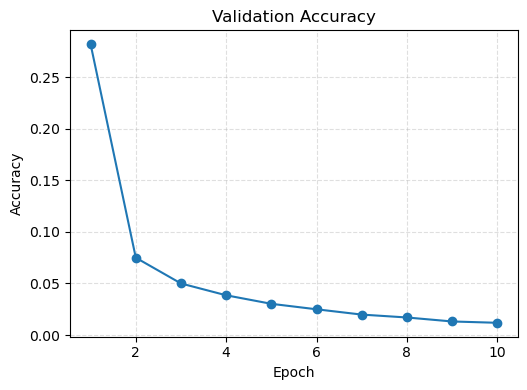

In [16]:
# 9.1) 训练曲线可视化
# 构造 epoch 轴
epochs_axis = list(range(1, len(epoch_losses) + 1))

# 创建画布
plt.figure(figsize=(10, 4))
# 左图：训练损失
plt.subplot(1, 2, 1)
plt.plot(epochs_axis, epoch_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.4)

# 右图：验证准确率（若有）
#plt.subplot(1, 2, 2)
valid_acc = [a for a in epoch_accs if a is not None]
valid_epochs = [i + 1 for i, a in enumerate(epoch_accs) if a is not None]
if valid_acc:
    plt.plot(valid_epochs, valid_acc, marker="o", color="green")
    plt.ylim(0, 1)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.4)

# 调整布局并显示
plt.tight_layout()
plt.show()

## 10) 训练后单图验证与可选模型加载推理

In [ ]:
# 训练后随机抽样做一次单图验证
single_sample_check(model, test_dataset)

# 可选：加载某个 checkpoint 后再做单图推理
# model2 = MyCNN()
# model2.load_state_dict(torch.load(os.path.join(checkpoint_dir, "model_epoch_8.pth"), map_location="cpu"))
# single_sample_check(model2, test_dataset)


Single Image Validation
Image: d:\CZ_WorkSpace\ai学习\深度学习实践\task1\MNIST_kaggle\testSet\img_7064.jpg
Pred Label: 7, Confidence: 0.6555 (no ground-truth label)


In [ ]:
# 11) 加载模型参数并对测试集推理（导出 Kaggle 提交文件）
# 引入 DataLoader 以便批量推理
from torch.utils.data import DataLoader

# TODO: 修改为你要加载的权重文件路径
ckpt_path = os.path.join(checkpoint_dir, "model_epoch_8.pth")

# 初始化模型并加载权重
infer_model = MyCNN()
infer_model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
infer_model.eval()

# 构建推理 DataLoader（无标签）
infer_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
pred_records = []
with torch.no_grad():
    for images, file_paths in infer_loader:
        # 前向推理得到 logits
        logits = infer_model(images)
        # 取最大值所在类别作为预测结果
        preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()
        for path, pred in zip(file_paths, preds):
            # 从文件名中解析 ImageId
            base = os.path.basename(path)
            match = re.search(r"\d+", base)
            if match is None:
                raise ValueError(f"Cannot parse image id from filename: {base}")
            image_id = int(match.group())
            pred_records.append((image_id, pred))

# 按 ImageId 升序排序，符合 Kaggle 提交格式
pred_records.sort(key=lambda x: x[0])
submit_df = pd.DataFrame(pred_records, columns=["ImageId", "Label"])

# 保存提交文件到当前工作目录
submit_path = os.path.join(os.getcwd(), "kaggle_submit.csv")
submit_df.to_csv(submit_path, index=False)
print(f"Saved submission file: {submit_path}")
print(submit_df.head())

Saved submission file: d:\CZ_WorkSpace\ai学习\深度学习实践\task1\task1_2\kaggle_submit.csv
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3
